# CAR INSURANCE 
## Goal:- predicts if an insurance claim is fraudulent or not.

### This project aims to develop a predictive model that helps insurance companies detect fraudulant claims and reduce financial losses.

## Import libraries

In [1]:
## Data handling
import pandas as pd

## Numerical Computation
import numpy as np

## Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Machine Learning(scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix

## Load 
import pickle

## warnings
import warnings
warnings.filterwarnings("ignore")


## Load Dataset

In [2]:
df = pd.read_csv("car_insur.csv")
## for all columns are visible
pd.set_option('display.max_columns',None)
## Displaying The First Few Rows
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,13-06-2024,Parked Car,Front,Total Loss,NaN,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,23-03-2025,Vehicle Theft,Rear,Total Loss,NaN,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,26-01-2025,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,03-06-2024,Parked Car,Rear,Total Loss,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,21-05-2024,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


##  Understanding Data

In [3]:
print("TOTAL(ROW,COLUMN)",df.shape)

TOTAL(ROW,COLUMN) (30000, 24)


In [4]:
## check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [5]:
## Statistical summary
df.describe()

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,562.783333,1051.255214,46.500133,11.505000,2.508933,1.997600,2.504667,10823.078981,12757.736600
std,250.413012,260.357163,16.707778,6.896155,1.116555,1.411829,1.707691,6629.690781,7028.920069
min,200.000000,600.020000,18.000000,0.000000,1.000000,0.000000,0.000000,266.740000,502.180000
25%,300.000000,826.320000,32.000000,6.000000,2.000000,1.000000,1.000000,5350.947500,6685.507500
50%,600.000000,1051.155000,46.000000,12.000000,3.000000,2.000000,2.000000,10204.170000,12740.430000
75%,800.000000,1277.902500,61.000000,17.000000,4.000000,3.000000,4.000000,15381.867500,18809.910000
max,1000.000000,1499.980000,75.000000,23.000000,4.000000,4.000000,5.000000,29719.870000,24999.720000


### Overview:-

Insured age ranges from 18 to 75 years, average is about 46 years

Usually 2–3 vehicles are involved in an accident

Most accidents have 1–3 injuries and 1–3 witnesses.

______________________________________________________________________


In [6]:
## See the features name
df.columns

Index(['policy_id', 'policy_state', 'policy_deductible',
       'policy_annual_premium', 'insured_age', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'police_report_available',
       'claim_amount', 'total_claim_amount', 'fraud_reported'],
      dtype='object')

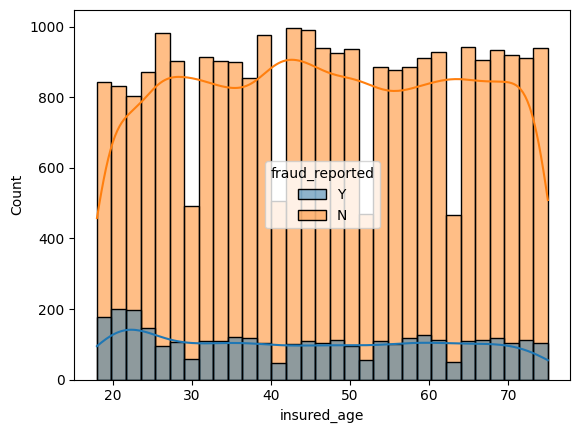

In [7]:
# "Distribution of Insured Age by Fraud Status"
sns.histplot(data=df, x='insured_age', hue='fraud_reported', kde=True)
plt.show()


###  Overview:-

Fraudulent and non-fraudulent claims are spread across all age groups (20 to 75), suggesting that age is not a strong  indicator for fraud.

The highest density of claims occurs in the 30–50 age bracket, which likely represents the most active driving population.

_________________________________________________

## Data Cleaning

## Drop Unwanted Column

In [8]:
o = df.drop(['policy_id',"incident_date","incident_city","insured_hobbies","policy_state",
         "incident_hour_of_the_day","witnesses","collision_type"], axis=1,inplace=True)

## Missing Value Handeling

<Axes: >

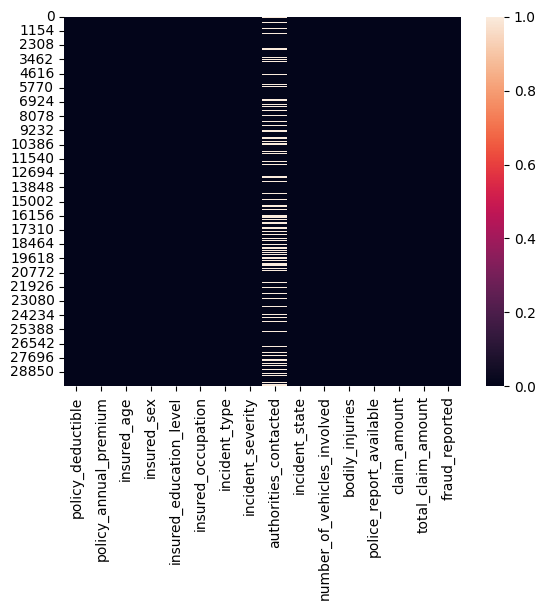

In [9]:
### Using plot
sns.heatmap(df.isnull())

In [10]:
## How Many Missing value do we have?
null_vall = df.isnull().sum().sum()
print(f'There are {null_vall} NaN in this dataset')

## percent of data that is missing
null_val_per = (null_vall/len(df)*100)
print(f"total {null_val_per} % missing Value is present")

There are 7564 NaN in this dataset
total 25.21333333333333 % missing Value is present


______________________________________________________

#### Sometimes the authority contact is not available in case of incurance claim amount action. So we fill with UNKOWN.

In [11]:
df['authorities_contacted'].fillna('unknown',inplace=True)

## Check Duplicates

In [12]:
duplicat = df.duplicated().sum()
print(f"There are {duplicat} duplicate value is this dataset")

There are 0 duplicate value is this dataset


## Outlier Detection

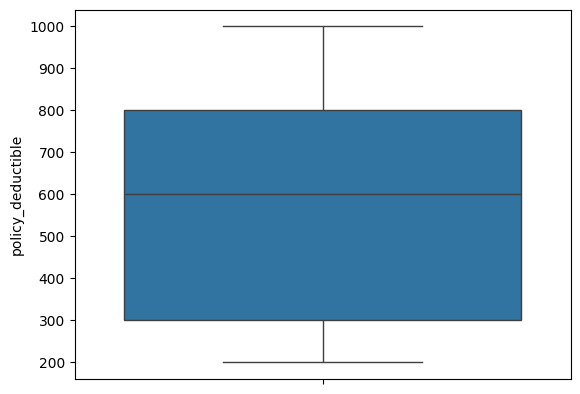

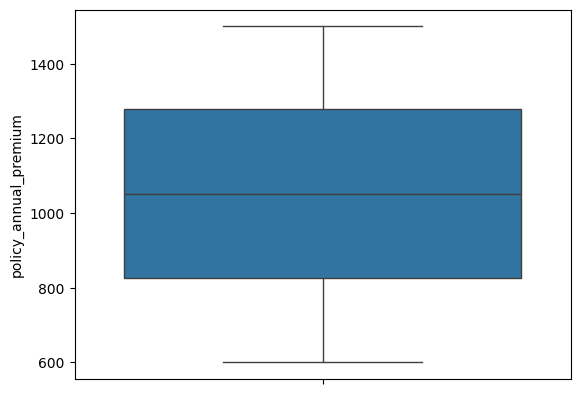

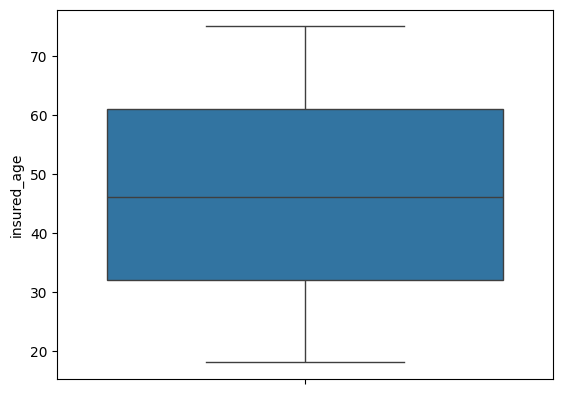

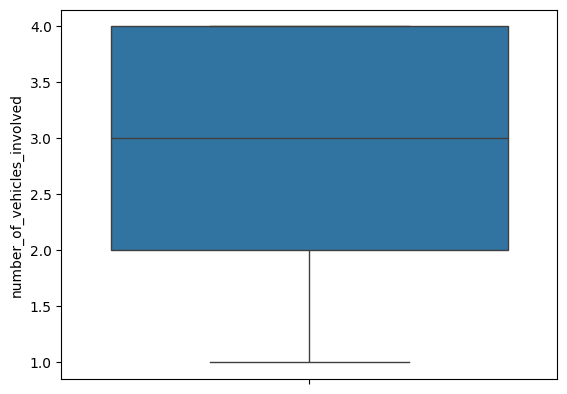

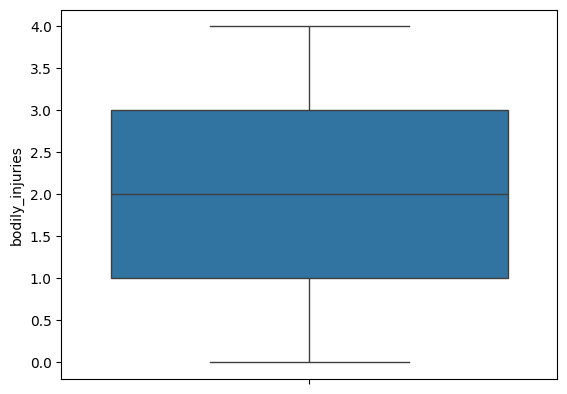

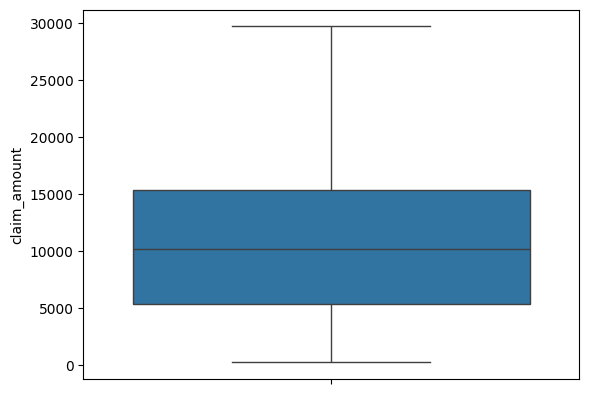

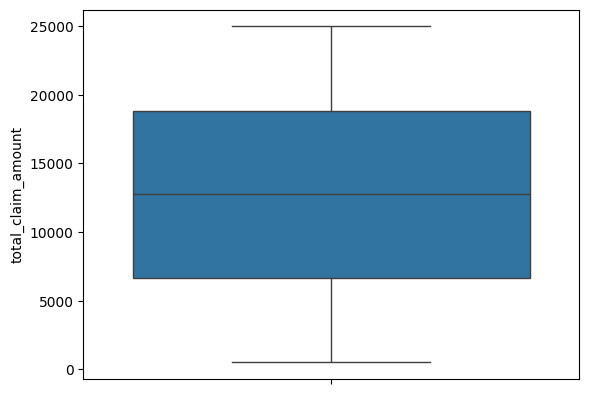

In [13]:
cols = ['policy_deductible',	'policy_annual_premium',	'insured_age',
'number_of_vehicles_involved',	'bodily_injuries','claim_amount',	'total_claim_amount']

for col in cols:
    plt.figure()
    sns.boxplot(df[col])
    plt.show()

### No outlier
---------------------------------------------------------------------------------------------------------------

## Skewness Treatment

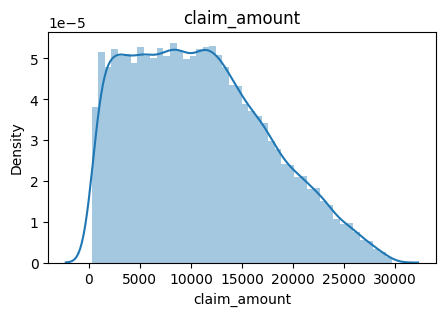

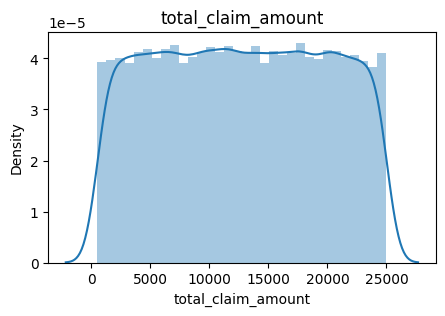

In [14]:
num_cols = ['claim_amount',	'total_claim_amount']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.distplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [15]:
for col in cols:
    print(col)
    print("skew",df[col].skew())
    print("*******************")

policy_deductible
skew 0.2349754188604925
*******************
policy_annual_premium
skew -0.002157174725053985
*******************
insured_age
skew 0.0054842796825078045
*******************
number_of_vehicles_involved
skew -0.008102580831995004
*******************
bodily_injuries
skew 0.002896735432756383
*******************
claim_amount
skew 0.44219278384777666
*******************
total_claim_amount
skew 0.0018905007386192311
*******************


#### Almost Normal distribution
------------------------------------------------------------------------------------------------------------

#### Encoding

In [16]:
le = LabelEncoder()

colss = ['insured_sex','insured_education_level','insured_occupation',
         'incident_type','incident_severity','authorities_contacted',"incident_state",
         "police_report_available"]


for col in colss:
    df[col]=le.fit_transform(df[col])

In [17]:
df.head()

,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,incident_type,incident_severity,authorities_contacted,incident_state,number_of_vehicles_involved,bodily_injuries,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,400,1430.78,74,2,1,4,1,2,3,4,1,4,1,8161.36,11677.60,Y
1,300,854.49,74,1,0,3,3,2,3,7,3,4,0,18561.79,18027.81,N
2,400,1247.28,28,2,3,1,1,2,2,4,4,4,0,10734.61,10375.59,N
3,600,622.42,37,1,3,6,1,2,2,5,3,3,0,13188.92,14204.34,N
4,700,1458.17,31,2,3,5,2,1,1,6,4,2,0,21864.69,24038.84,N


In [18]:
input_data = df.iloc[:,:-1]
output_data = df['fraud_reported']

## Train Test Split

In [19]:
# from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(input_data,output_data,test_size=0.2,random_state=42)

In [20]:
print("X_test (row,column)",x_test.shape)
print("y_test (row,column)",y_test.shape)
print("X_train (row,column)",x_train.shape)
print("y_train (row,column)",y_train.shape)

X_test (row,column) (6000, 15)
y_test (row,column) (6000,)
X_train (row,column) (24000, 15)
y_train (row,column) (24000,)


## Feature scaling

In [21]:
# from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

x_train_scal = mm.fit_transform(x_train)
x_test_scal = mm.fit_transform(x_test)

## Model Training

In [22]:
# from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Pridiction

In [23]:
y_pred = lr.predict(x_test)

## Evaluation

In [24]:
print(f"total accuracy score is {accuracy_score(y_test,y_pred)*100} %")

total accuracy score is 88.53333333333333 %
